# Awareness Factor Investigation 

These are experimental codes:      
- Briefing the data
- Tuning optimal hyperparameter
- Visualize the performance of Models
- Visualize the importance
- Visualize and summerize impacts

In [36]:
%pwd

'/mnt/d/OneDrive/MLD01_Article'

In [2]:
%cd ..

/mnt/d/OneDrive/MLD01_Article


/home/linux/anaconda3/envs/tf/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Import PAckage

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from xgboost import XGBClassifier 

## Append Data

In [4]:
df_2016 = pd.read_parquet('Data/01_Napel2016.parquet')
df_2016['Year'] = 2016
df_2022 = pd.read_parquet('Data/01_Napel2022.parquet')
df_2022['Year'] = 2022

In [5]:
df_all = pd.concat([df_2016, df_2022], axis = 0)

In [6]:
df_all.shape

(11568, 352)

In [7]:
df_all = df_all.dropna(axis=1, how="any")

In [8]:
df_all.shape

(11568, 277)

In [9]:
df_all = df_all.set_index(['PSU', 'HHLD'])

In [10]:
df_all.columns

Index(['EcoBelt', 'Prov', 'Rural_Dummy', 'Respon_Female', 'Respon_Age',
       'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor',
       'Edu_Master',
       ...
       'SoilWaterConservationPast25', 'VisitClimateOfficePast25',
       'FoodConsumptionHabitPast25', 'OfffarmActiPast25',
       'NonFarmEmployPast25', 'FamilyMigrationPast25', 'RiskReductionPast25',
       'RoadImprovementPast25', 'CommunityPartipationPast25', 'Year'],
      dtype='object', length=275)

In [11]:
df_all["EcoBelt"] = df_all["EcoBelt"].str.replace('Tarai', 'Terai')

In [12]:
eco_dummies = pd.get_dummies(df_all["EcoBelt"], prefix="EcoBelt").astype(int)
df_all = pd.concat([df_all, eco_dummies], axis=1)

In [13]:
prov_dummies = pd.get_dummies(df_all["Prov"], prefix="Prov").astype(int)
df_all = pd.concat([df_all, prov_dummies], axis=1)

In [14]:
df_all

EcoBelt          Prov  Rural_Dummy  Respon_Female  Respon_Age  \
PSU   HHLD                                                                   
101.0 1.0   Mountain         Koshi            1            1.0        49.0   
      2.0   Mountain         Koshi            1            0.0        55.0   
      3.0   Mountain         Koshi            1            1.0        46.0   
      4.0   Mountain         Koshi            1            0.0        78.0   
      5.0   Mountain         Koshi            1            0.0        70.0   
...              ...           ...          ...            ...         ...   
826.0 16.0     Terai  Sudurpaschim            0            0.0        47.0   
      17.0     Terai  Sudurpaschim            0            0.0        60.0   
      18.0     Terai  Sudurpaschim            0            1.0        47.0   
      19.0     Terai  Sudurpaschim            0            0.0        55.0   
      20.0     Terai  Sudurpaschim            0            0.0        45.0   

            LivingYear  Edu_UnderSLC  Edu_Certificate  Edu_Bachelor  \
PSU   HHLD                                                            
101.0 1.0         49.0             0                0             0   
      2.0         55.0             1                0             0   
      3.0         25.0             0                0             0   
      4.0         78.0             0                0             0   
      5.0         70.0             1                0             0   
...                ...           ...              ...           ...   
826.0 16.0        40.0             1                0             0   
      17.0        35.0             0                0             0   
      18.0        32.0             1                0             0   
      19.0        55.0             0                0             0   
      20.0        25.0             1                0             0   

            Edu_Master  ...  EcoBelt_Hill  EcoBelt_Mountain  EcoBelt_Terai  \
PSU   HHLD              ...                                                  
101.0 1.0            0  ...             0                 1              0   
      2.0            0  ...             0                 1              0   
      3.0            0  ...             0                 1              0   
      4.0            0  ...             0                 1              0   
      5.0            0  ...             0                 1              0   
...                ...  ...           ...               ...            ...   
826.0 16.0           0  ...             0                 0              1   
      17.0           0  ...             0                 0              1   
      18.0           0  ...             0                 0              1   
      19.0           0  ...             0                 0              1   
      20.0           0  ...             0                 0              1   

            Prov_Bagmati  Prov_Gandaki  Prov_Karnali  Prov_Koshi  \
PSU   HHLD                                                         
101.0 1.0              0             0             0           1   
      2.0              0             0             0           1   
      3.0              0             0             0           1   
      4.0              0             0             0           1   
      5.0              0             0             0           1   
...                  ...           ...           ...         ...   
826.0 16.0             0             0             0           0   
      17.0             0             0             0           0   
      18.0             0             0             0           0   
      19.0             0             0             0           0   
      20.0             0             0             0           0   

            Prov_Lumbini  Prov_Madhesh  Prov_Sudurpaschim  
PSU   HHLD                                                 
101.0 1.0              0             0                

### Revise Income Resources

In [15]:
df_all['IncomeResAgri_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 1).any(axis=1).astype(int)
df_all['IncomeResWage_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 2).any(axis=1).astype(int)
df_all['IncomeResNonAgriBusi_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 3).any(axis=1).astype(int)
df_all['IncomeResRemit_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 4).any(axis=1).astype(int)
df_all['IncomeResOthers_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 5).any(axis=1).astype(int)

In [16]:
df_all['ResidenceOwn_dummy'] = (df_all['Own_Resid'] == 1).astype(int)
df_all['ResidenceRent_dummy'] = (df_all['Own_Resid'] == 2).astype(int)
df_all['ResidenceInstitu_dummy'] = (df_all['Own_Resid'] == 3).astype(int)
df_all['ResidenceOthers_dummy'] = (df_all['Own_Resid'] == 4).astype(int)

In [17]:
df_all['ResidInfraPerman_dummy'] = (df_all['Resid_Type'] == 1).astype(int)
df_all['ResidInfraSemi_dummy'] = (df_all['Resid_Type'] == 2).astype(int)
df_all['ResidInfraKachchi_dummy'] = (df_all['Resid_Type'] == 3).astype(int)
df_all['ResidInfraOthers_dummy'] = (df_all['Resid_Type'] == 4).astype(int)

## Checking "ClimateChanged_Dummy"

### Dataset building

In [18]:
print(df_all.columns.tolist())

['EcoBelt', 'Prov', 'Rural_Dummy', 'Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor', 'Edu_Master', 'Edu_PhD', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year', 'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', 'Household_memberNum', 'Own_Resid', 'Resid_Type', 'WaterS1', 'WaterS2', 'WaterS3', 'CookFuelS1', 'CookFuelS2', 'CookFuelS3', 'LightEnergy', 'Toilet', 'IncomeS1', 'IncomeS2', 'IncomeS3', 'Remittance_dummy', 'Have_AgriLand', 'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy', 'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy', 'HouseHead_AgriExpYear', 'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport', 'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 'FramMechan', 'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome', 'HeardClimate_Dummy', 'ClimateChanged_Dummy', 'ClimateInf

In [19]:
df_inuse = df_all[['ClimateChanged_Dummy', 'HeardClimate_Dummy', 
                   'Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 
                   'Edu_Bachelor', 'Edu_Master', 'Edu_PhD', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year', # S01
                   'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', # S02-1
                   'EcoBelt_Hill', 'EcoBelt_Mountain', 'EcoBelt_Terai', 
                   'Prov_Bagmati', 'Prov_Koshi', 'Prov_Lumbini', 'Prov_Madhesh', 'Prov_Sudurpaschim',
                   'Prov_Gandaki', 'Prov_Karnali', # location     
                   'ResidenceOwn_dummy', 'ResidenceRent_dummy', 'ResidenceInstitu_dummy', 'ResidenceOthers_dummy',
                   'ResidInfraPerman_dummy', 'ResidInfraSemi_dummy', 'ResidInfraKachchi_dummy', 'ResidInfraOthers_dummy', # house
                    'Remittance_dummy', 
                   'Have_AgriLand', 'HouseHead_AgriExpYear',
                   'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy',
                   'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
                   'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport', 
                   'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 
                   'FramMechan',
                    'IncomeResAgri_dummy', 'IncomeResWage_dummy', 'IncomeResNonAgriBusi_dummy', 'IncomeResRemit_dummy',
                   'IncomeResOthers_dummy', 
                   'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome',
                   'Year',
                   
                   # Awareness sources
                   'ClimateInfo_Radio', 'ClimateInfo_Telev', 'ClimateInfo_News ', 
                   'ClimateInfo_Aware', 'ClimateInfo_Local', 'ClimateInfo_Neigh', 
                   'ClimateInfo_Famil', 'ClimateInfo_Other',
                   
                   # Disaster experiences
                   'ExpDummyDR', 'ExpDummyFF', 'ExpDummyFS', 'ExpDummyFL', 'ExpDummyIN', 'ExpDummyWS', 
                   'ExpDummyTS', 'ExpDummyHS', 'ExpDummyHR', 'ExpDummySR', 'ExpDummySE', 'ExpDummyLS', 
                   'ExpDummySS', 'ExpDummyAV', 'ExpDummyGLOF', 'ExpDummyHW', 'ExpDummyCW', 'ExpDummyDI', 
                   'ExpDummyOT',
                   
                   # DisasterFoodShortage
                   'DisasterFoodShortage_DummyDR', 'DisasterFoodShortage_DummyFF', 'DisasterFoodShortage_DummyFS', 
                   'DisasterFoodShortage_DummyFL', 'DisasterFoodShortage_DummyIN', 'DisasterFoodShortage_DummyWS', 
                   'DisasterFoodShortage_DummyTS', 'DisasterFoodShortage_DummyHS', 'DisasterFoodShortage_DummyHR', 
                   'DisasterFoodShortage_DummySR', 'DisasterFoodShortage_DummySE', 'DisasterFoodShortage_DummyLS', 
                   'DisasterFoodShortage_DummySS', 'DisasterFoodShortage_DummyAV', 'DisasterFoodShortage_DummyGLOF', 
                   'DisasterFoodShortage_DummyHW', 'DisasterFoodShortage_DummyCW', 'DisasterFoodShortage_DummyDI', 
                   'DisasterFoodShortage_DummyOT', 'DisasterDie_DummyDR', 
                   
                   # DisasterDie
                   'DisasterDie_DummyFF', 'DisasterDie_DummyFS', 'DisasterDie_DummyFL', 'DisasterDie_DummyIN', 
                   'DisasterDie_DummyWS', 'DisasterDie_DummyTS', 'DisasterDie_DummyHS', 'DisasterDie_DummyHR', 
                   'DisasterDie_DummySR', 'DisasterDie_DummySE', 'DisasterDie_DummyLS', 'DisasterDie_DummySS', 
                   'DisasterDie_DummyAV', 'DisasterDie_DummyGLOF', 'DisasterDie_DummyHW', 'DisasterDie_DummyCW', 
                   'DisasterDie_DummyDI', 'DisasterDie_DummyOT', 
                   
                   # DisasterMoneyLoss
                   'DisasterMoneyLoss_DummyDR', 'DisasterMoneyLoss_DummyFF', 'DisasterMoneyLoss_DummyFS', 
                   'DisasterMoneyLoss_DummyFL', 'DisasterMoneyLoss_DummyIN', 'DisasterMoneyLoss_DummyWS', 
                   'DisasterMoneyLoss_DummyTS', 'DisasterMoneyLoss_DummyHS', 'DisasterMoneyLoss_DummyHR', 
                   'DisasterMoneyLoss_DummySR', 'DisasterMoneyLoss_DummySE', 'DisasterMoneyLoss_DummyLS', 
                   'DisasterMoneyLoss_DummySS', 'DisasterMoneyLoss_DummyAV', 'DisasterMoneyLoss_DummyGLOF',
                   'DisasterMoneyLoss_DummyHW', 'DisasterMoneyLoss_DummyCW', 'DisasterMoneyLoss_DummyDI', 
                   'DisasterMoneyLoss_DummyOT', 
                   
]]

In [20]:
variname_readable = {'ClimateChanged_Dummy':'Climate Change Awareness Dummy',
                     'HeardClimate_Dummy':'Heard about Climate Change Dummy', 'Respon_Female':'Female Dummy', 
                     'Respon_Age':'Age', 'LivingYear':'Years Living in Community', 'Edu_UnderSLC':'Education under Secondary Certificate Dummy', 
                     'Edu_Certificate':'Education with Secondary Certificate Dummy', 'Edu_Bachelor':'Education with Bachelor Dummy', 
                     'Edu_Master':'Education with Master Dummy',  'Edu_PhD':'Education with PhD Dummy', 
                     'Edu_Literal':'Literate Education Dummy',  'Edu_Illiterate':'Illiterate Dummy', 'Edu_year':'Education Year',
                     'Female_Ratio':'Female Ratio in Household', 'U18_Ratio':'Member Under 18 Ratio', 'A65_Ratio':'Seniors Ratio',
                     'Edu12_Ratio':"Member with 12-Year Education or above Ratio", "Literal_Ratio": "Literate Member Ratio",
                     'EcoBelt_Hill': "EcoBelt Hill Dummy", 'EcoBelt_Mountain': "EcoBelt Mountain Dummy", 'EcoBelt_Terai': "EcoBelt Terai Dummy",
                     'Prov_Bagmati': "Province Bagmati Dummy", 'Prov_Koshi': "Province Koshi Dummy", 'Prov_Lumbini': "Province Lumbibi Dummy",
                     'Prov_Madhesh': "Province Madhesh Dummy", 'Prov_Sudurpaschim': "Province Sudurpaschim Dummy", 'Prov_Gandaki': "Province Gandaki Dummy",
                     'Prov_Karnali': "Province Karnali Dummy",
                     'ResidenceOwn_dummy': "Owned Residence Ownership Dummy", 'ResidenceRent_dummy': 'Rented Residence Ownership Dummy', 
                     'ResidenceInstitu_dummy': 'Institutional Residence Ownership Dummy', 'ResidenceOthers_dummy': 'Other-type Residence Ownership Dummy',
                     'ResidInfraPerman_dummy': 'Permanent Residence Dummy', 'ResidInfraSemi_dummy': 'Semi-Permanent Residence Dummy', 
                     'ResidInfraKachchi_dummy': "Kachchi Residence Dummy", 'ResidInfraOthers_dummy': 'Other Residence Infrastructure Dummy', # house
                     'Remittance_dummy' : "Have Remittance",
                     'Have_AgriLand': "Having Agricultural Land Dummy", 'HouseHead_AgriExpYear': "Household Head Agricultural Experience",
                     'Radio_dummy': "Having Radio Dummy", 'TV_dummy': "Having TV Dummy", 'PC_dummy': "Having Computer Dummy", 'Net_dummy': "Having Internet Dummy",
                     'Phone_dummy': "Having Telephone Dummy", 'Mobile_dummy': "Having Mobile Dummy", 'Motorbike_dummy': "Having Motorbike Dummy", 
                     'Car_dummy': "Having Car Dummy", 'Bike_dummy': "Having Bike Dummy", 'OtherVehi_dummy': "Having Other Vehicle Dummy", 
                     'Refrige_dummy':"Having Refrigator Dummy",
                     'SavingMembership': "Saving Membership Dummy", 'RegularSaving': 'Having Regular Saving Dummy', 
                     'OrgMembership': 'Having Organization Membership Dummy', 'AgriSupport':'Agricultural Supporting Dummy', 
                     'Dist_Road': 'Distance to Motorable Road', 'Dist_HealthCenter': "Distance to Health Center", 
                     'Dist_SecondarySchool': "Distance to Secondary School", 'Dist_Market':"Distance to Market", 'Dist_AgriSupport': 'Distance to Agricultural Center', 
                     'FramMechan':'Farm Mechanization Dummy',
                     'IncomeResAgri_dummy': "Agricultural Income Source Dummy", 'IncomeResWage_dummy': "Wage Income Source Dummy",
                     'IncomeResNonAgriBusi_dummy': "Non-Agricultural Business Income Source Dummy", 'IncomeResRemit_dummy': "Remittance Income Dummy",
                     'IncomeResOthers_dummy': "Others Income Source Dummy", 
                     'CropIncome': "Crop Income", 'LivestockIncome': "Livestock Income", 'NonAgriIncome': "Non-agricultural Income", 
                     'BusiIncome': "Business Income", 'TotalIncome': "Total Income",
                     'Year': "Survey Year",
                                         
                    }

In [21]:
# ...existing code...
variname_readable.update({
    # Awareness sources
    'ClimateInfo_Radio': "Heard Climate Info from Radio",
    'ClimateInfo_Telev': "Heard Climate Info from Television",
    'ClimateInfo_News ': "Heard Climate Info from Newspaper",
    'ClimateInfo_Aware': "Heard Climate Info from Awareness Program",
    'ClimateInfo_Local': "Heard Climate Info from Local Government",
    'ClimateInfo_Neigh': "Heard Climate Info from Neighbors",
    'ClimateInfo_Famil': "Heard Climate Info from Family",
    'ClimateInfo_Other': "Heard Climate Info from Other Sources",

    # Disaster experiences
    'ExpDummyDR': "Experienced Drought",
    'ExpDummyFF': "Experienced Flash Flood",
    'ExpDummyFS': "Experienced Forest Fire",
    'ExpDummyFL': "Experienced Flood",
    'ExpDummyIN': "Experienced Insect Infestation",
    'ExpDummyWS': "Experienced Windstorm",
    'ExpDummyTS': "Experienced Thunderstorm",
    'ExpDummyHS': "Experienced Hailstorm",
    'ExpDummyHR': "Experienced Heavy Rain",
    'ExpDummySR': "Experienced Snowfall/Rain",
    'ExpDummySE': "Experienced Earthquake",
    'ExpDummyLS': "Experienced Landslide",
    'ExpDummySS': "Experienced Snowstorm",
    'ExpDummyAV': "Experienced Avalanche",
    'ExpDummyGLOF': "Experienced Glacial Lake Outburst Flood",
    'ExpDummyHW': "Experienced Heat Wave",
    'ExpDummyCW': "Experienced Cold Wave",
    'ExpDummyDI': "Experienced Disease Outbreak",
    'ExpDummyOT': "Experienced Other Disaster",

    # Disaster Food Shortage
    'DisasterFoodShortage_DummyDR': "Food Shortage due to Drought",
    'DisasterFoodShortage_DummyFF': "Food Shortage due to Flash Flood",
    'DisasterFoodShortage_DummyFS': "Food Shortage due to Forest Fire",
    'DisasterFoodShortage_DummyFL': "Food Shortage due to Flood",
    'DisasterFoodShortage_DummyIN': "Food Shortage due to Insect Infestation",
    'DisasterFoodShortage_DummyWS': "Food Shortage due to Windstorm",
    'DisasterFoodShortage_DummyTS': "Food Shortage due to Thunderstorm",
    'DisasterFoodShortage_DummyHS': "Food Shortage due to Hailstorm",
    'DisasterFoodShortage_DummyHR': "Food Shortage due to Heavy Rain",
    'DisasterFoodShortage_DummySR': "Food Shortage due to Snowfall/Rain",
    'DisasterFoodShortage_DummySE': "Food Shortage due to Earthquake",
    'DisasterFoodShortage_DummyLS': "Food Shortage due to Landslide",
    'DisasterFoodShortage_DummySS': "Food Shortage due to Snowstorm",
    'DisasterFoodShortage_DummyAV': "Food Shortage due to Avalanche",
    'DisasterFoodShortage_DummyGLOF': "Food Shortage due to GLOF",
    'DisasterFoodShortage_DummyHW': "Food Shortage due to Heat Wave",
    'DisasterFoodShortage_DummyCW': "Food Shortage due to Cold Wave",
    'DisasterFoodShortage_DummyDI': "Food Shortage due to Disease Outbreak",
    'DisasterFoodShortage_DummyOT': "Food Shortage due to Other Disaster",
    'DisasterDie_DummyDR': "Death due to Drought",

    # Disaster Die
    'DisasterDie_DummyFF': "Death due to Flash Flood",
    'DisasterDie_DummyFS': "Death due to Forest Fire",
    'DisasterDie_DummyFL': "Death due to Flood",
    'DisasterDie_DummyIN': "Death due to Insect Infestation",
    'DisasterDie_DummyWS': "Death due to Windstorm",
    'DisasterDie_DummyTS': "Death due to Thunderstorm",
    'DisasterDie_DummyHS': "Death due to Hailstorm",
    'DisasterDie_DummyHR': "Death due to Heavy Rain",
    'DisasterDie_DummySR': "Death due to Snowfall/Rain",
    'DisasterDie_DummySE': "Death due to Earthquake",
    'DisasterDie_DummyLS': "Death due to Landslide",
    'DisasterDie_DummySS': "Death due to Snowstorm",
    'DisasterDie_DummyAV': "Death due to Avalanche",
    'DisasterDie_DummyGLOF': "Death due to GLOF",
    'DisasterDie_DummyHW': "Death due to Heat Wave",
    'DisasterDie_DummyCW': "Death due to Cold Wave",
    'DisasterDie_DummyDI': "Death due to Disease Outbreak",
    'DisasterDie_DummyOT': "Death due to Other Disaster",

    # Disaster Money Loss
    'DisasterMoneyLoss_DummyDR': "Money Loss due to Drought",
    'DisasterMoneyLoss_DummyFF': "Money Loss due to Flash Flood",
    'DisasterMoneyLoss_DummyFS': "Money Loss due to Forest Fire",
    'DisasterMoneyLoss_DummyFL': "Money Loss due to Flood",
    'DisasterMoneyLoss_DummyIN': "Money Loss due to Insect Infestation",
    'DisasterMoneyLoss_DummyWS': "Money Loss due to Windstorm",
    'DisasterMoneyLoss_DummyTS': "Money Loss due to Thunderstorm",
    'DisasterMoneyLoss_DummyHS': "Money Loss due to Hailstorm",
    'DisasterMoneyLoss_DummyHR': "Money Loss due to Heavy Rain",
    'DisasterMoneyLoss_DummySR': "Money Loss due to Snowfall/Rain",
    'DisasterMoneyLoss_DummySE': "Money Loss due to Earthquake",
    'DisasterMoneyLoss_DummyLS': "Money Loss due to Landslide",
    'DisasterMoneyLoss_DummySS': "Money Loss due to Snowstorm",
    'DisasterMoneyLoss_DummyAV': "Money Loss due to Avalanche",
    'DisasterMoneyLoss_DummyGLOF': "Money Loss due to GLOF",
    'DisasterMoneyLoss_DummyHW': "Money Loss due to Heat Wave",
    'DisasterMoneyLoss_DummyCW': "Money Loss due to Cold Wave",
    'DisasterMoneyLoss_DummyDI': "Money Loss due to Disease Outbreak",
    'DisasterMoneyLoss_DummyOT': "Money Loss due to Other Disaster",
})
# ...existing code...

In [22]:
data_summary = df_inuse.describe().T

In [23]:
data_summary.index = data_summary.index.map(variname_readable)

In [24]:
data_summary.to_excel("MLD01e_Results/Table03_DataSummaryAwareness_v2.xlsx")

In [25]:
data_summary

,count,mean,std,min,25%,50%,75%,max
Climate Change Awareness Dummy,11568.0,0.901020,0.298648,0.0,1.0,1.0,1.0,1.0
Heard about Climate Change Dummy,11568.0,0.421508,0.493822,0.0,0.0,0.0,1.0,1.0
Female Dummy,11568.0,0.285183,0.451521,0.0,0.0,0.0,1.0,1.0
Age,11568.0,58.681189,10.276510,45.0,50.0,58.0,66.0,95.0
Years Living in Community,11568.0,50.082382,15.829423,25.0,40.0,50.0,60.0,730.0
...,...,...,...,...,...,...,...,...
Money Loss due to GLOF,11568.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Money Loss due to Heat Wave,11568.0,0.000519,0.022769,0.0,0.0,0.0,0.0,1.0
Money Loss due to Cold Wave,11568.0,0.020228,0.140786,0.0,0.0,0.0,0.0,1.0
Money Loss due to Disease Outbreak,11568.0,0.127161,0.333168,0.0,0.0,0.0,0.0,1.0


In [26]:
df_inuse.columns = df_inuse.columns.map(variname_readable)

## Hyper Tunining

In [27]:
y = df_inuse['Climate Change Awareness Dummy'].astype(int)
X = df_inuse.drop(columns=['Climate Change Awareness Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [28]:
clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    device = 'cuda'
)

In [29]:
param_distributions = {
    'n_estimators': [200, 500, 1_000, 2_000],
    'max_depth': [4,  8, 16],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 5, 10]
}

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=200,                 # increase for a more exhaustive search if you have time
    scoring='accuracy',
    return_train_score=True,
    cv=cv,
    verbose=3,
    refit=True,                # refit on entire data with best params
    random_state=42
)

search.fit(X, y)

Fitting 10 folds for each of 200 candidates, totalling 2000 fits


/home/linux/anaconda3/envs/tf/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [22:04:38] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


[CV 1/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=0.987, test=0.876) total time=   4.9s
[CV 2/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=0.986, test=0.879) total time=   4.0s
[CV 3/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=0.987, test=0.879) total time=   5.0s
[CV 4/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=0.986, test=0.889) total time=   4.8s
[CV 5/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=0.986, test=0.870) total time=   5.0s
[CV 6/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(

In [37]:
# 7) Results
print("Best mean CV accuracy:", f"{search.best_score_:.4f}")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Best mean CV accuracy: 0.8975
Best params:
  subsample: 0.9
  n_estimators: 500
  min_child_weight: 1
  max_depth: 16
  learning_rate: 0.1
  colsample_bytree: 0.9


In [38]:
cvres = pd.DataFrame(search.cv_results_)

In [39]:
cvres.to_parquet('MLD01e_Results/MLD01e_C02_AwarenessFactorInvestigation_v2.parquet')

In [40]:
cols = ['mean_test_score', 'std_test_score', 'rank_test_score'] + [c for c in cvres.columns if c.startswith('param_')]
cvres_sorted = cvres.sort_values('rank_test_score')[cols].head(10)

In [41]:
cvres_sorted

,mean_test_score,std_test_score,rank_test_score,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_colsample_bytree
131,0.897476,0.006553,1,0.9,500,1,16,0.1,0.9
92,0.897302,0.007783,2,0.9,1000,1,16,0.05,1.0
108,0.896957,0.007740,3,0.8,1000,1,16,0.05,1.0
88,0.896698,0.006299,4,1.0,2000,1,16,0.1,0.7
2,0.895660,0.007799,5,0.9,2000,1,8,0.05,0.9
56,0.894277,0.006455,6,1.0,1000,2,16,0.1,1.0
132,0.894018,0.006377,7,1.0,500,2,16,0.1,0.8
25,0.893845,0.007111,8,1.0,2000,2,16,0.1,1.0
161,0.893499,0.007939,9,0.8,2000,1,8,0.05,0.8
198,0.893067,0.007468,10,1.0,1000,2,16,0.05,0.9


## 10-fold 10-epoch Estimation

In [44]:
y = df_inuse['Climate Change Awareness Dummy'].astype(int)
X = df_inuse.drop(columns=['Climate Change Awareness Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [45]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [46]:
def Metrics(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_test, y_pred, zero_division=0))

    return [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0)]

In [47]:
prob_matrix = np.zeros([X.shape[0], 10])

In [48]:
acc_lines = []
importances_df = []
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for random_seed in range(42, 42*11, 42):
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            subsample = 0.9,
            n_estimators = 500,
            min_child_weight = 1,
            max_depth = 16,
            learning_rate = 0.1,
            colsample_bytree = 0.9, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)


        metrics = Metrics(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred).flatten()
        line  = [fold, random_seed] + metrics + list(cm)
        importances = clf.feature_importances_

        acc_lines.append(line)
        importances_df.append(importances)
        
    

fold: 1, random_seed:42
Accuracy: 0.8954191875540191
Precision: 0.9284386617100372
Recall   : 0.9578139980824545
F1-score : 0.9428975932043416
fold: 1, random_seed:84
Accuracy: 0.898876404494382
Precision: 0.9302973977695167
Recall   : 0.959731543624161
F1-score : 0.9447852760736196
fold: 1, random_seed:126
Accuracy: 0.8997407087294728
Precision: 0.9319664492078286
Recall   : 0.9587727708533078
F1-score : 0.945179584120983
fold: 1, random_seed:168
Accuracy: 0.898876404494382
Precision: 0.9287037037037037
Recall   : 0.9616490891658677
F1-score : 0.9448893075836081
fold: 1, random_seed:210
Accuracy: 0.9014693171996543
Precision: 0.9312906220984215
Recall   : 0.9616490891658677
F1-score : 0.9462264150943396
fold: 1, random_seed:252
Accuracy: 0.9014693171996543
Precision: 0.9312906220984215
Recall   : 0.9616490891658677
F1-score : 0.9462264150943396
fold: 1, random_seed:294
Accuracy: 0.9014693171996543
Precision: 0.9296947271045328
Recall   : 0.9635666347075743
F1-score : 0.946327683615819

In [49]:
acc_df = pd.DataFrame(acc_lines)

In [50]:
acc_df.columns = ['fold', 'random_seed', 'acc', 'prec', 'recall', 'f1', 'TN', 'FP', 'FN', 'TP']

In [51]:
acc_df.to_excel('MLD01e_Results/Table04_AccuracyTableAwareness_v2.xlsx')

In [52]:
acc_df[['acc', 'prec', 'recall', 'f1']].mean(axis=0)

acc       0.896456
prec      0.928254
recall    0.959234
f1        0.943481
dtype: float64

In [53]:
import_df = pd.DataFrame(importances_df).T

In [54]:
import_df.index = X.columns

In [55]:
import_df['Mean_Importance'] = import_df.iloc[:,:100].mean(axis = 1)
import_df['Std_Importance'] = import_df.iloc[:,:100].std(axis = 1)

In [56]:
import_df['Mean_Importance'] 

Heard about Climate Change Dummy               0.191721
Female Dummy                                   0.005383
Age                                            0.005123
Years Living in Community                      0.005101
Education under Secondary Certificate Dummy    0.004314
                                                 ...   
Money Loss due to GLOF                         0.000000
Money Loss due to Heat Wave                    0.000000
Money Loss due to Cold Wave                    0.003161
Money Loss due to Disease Outbreak             0.006853
Money Loss due to Other Disaster               0.000000
Name: Mean_Importance, Length: 154, dtype: float32

In [57]:
# Get importance values
importances = pd.Series(import_df['Mean_Importance'] , index=import_df.index)

# Sort descending
importances = importances.sort_values(ascending=False)

print(importances.head(20))   # Top 20 important features

Heard about Climate Change Dummy             0.191721
Survey Year                                  0.050752
Experienced Drought                          0.029234
Province Madhesh Dummy                       0.020856
Province Gandaki Dummy                       0.020484
Money Loss due to Windstorm                  0.018286
Heard Climate Info from Neighbors            0.017693
Heard Climate Info from Television           0.017583
Experienced Cold Wave                        0.017073
Food Shortage due to Hailstorm               0.014967
Heard Climate Info from Awareness Program    0.014194
Heard Climate Info from Radio                0.013663
Money Loss due to Landslide                  0.013495
Experienced Other Disaster                   0.012766
Experienced Forest Fire                      0.012485
Experienced Snowstorm                        0.012106
Having Mobile Dummy                          0.012010
Experienced Snowfall/Rain                    0.011905
Experienced Heavy Rain      

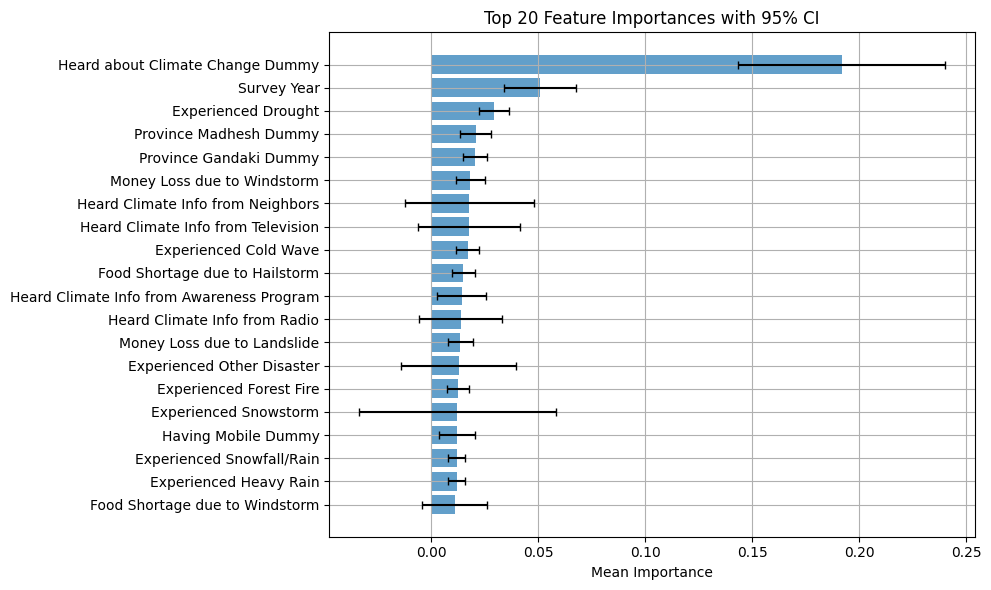

In [58]:
top20 = import_df.sort_values("Mean_Importance", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(
    top20.index, 
    top20["Mean_Importance"], 
    xerr=top20["Std_Importance"] * 1.96, 
    align="center", 
    alpha=0.7, 
    ecolor="black", 
    capsize=3
)
plt.xlabel("Mean Importance")
plt.title("Top 20 Feature Importances with 95% CI")
plt.grid()
plt.gca().invert_yaxis()  # largest on top
plt.tight_layout()
plt.show()

In [59]:
importances.head(20).index

Index(['Heard about Climate Change Dummy', 'Survey Year',
       'Experienced Drought', 'Province Madhesh Dummy',
       'Province Gandaki Dummy', 'Money Loss due to Windstorm',
       'Heard Climate Info from Neighbors',
       'Heard Climate Info from Television', 'Experienced Cold Wave',
       'Food Shortage due to Hailstorm',
       'Heard Climate Info from Awareness Program',
       'Heard Climate Info from Radio', 'Money Loss due to Landslide',
       'Experienced Other Disaster', 'Experienced Forest Fire',
       'Experienced Snowstorm', 'Having Mobile Dummy',
       'Experienced Snowfall/Rain', 'Experienced Heavy Rain',
       'Food Shortage due to Windstorm'],
      dtype='object')

## Compute Impact

### Heard about Climate Change Dummy

In [60]:
name = 'Heard about Climate Change Dummy'

In [61]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [62]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [63]:
prob_matrix.mean().mean()

0.197443753607213

In [64]:
prob_matrix.mean().std()

0.004709795334143735

In [65]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

0.20667495246213471

In [66]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

0.1882125547522913

In [67]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

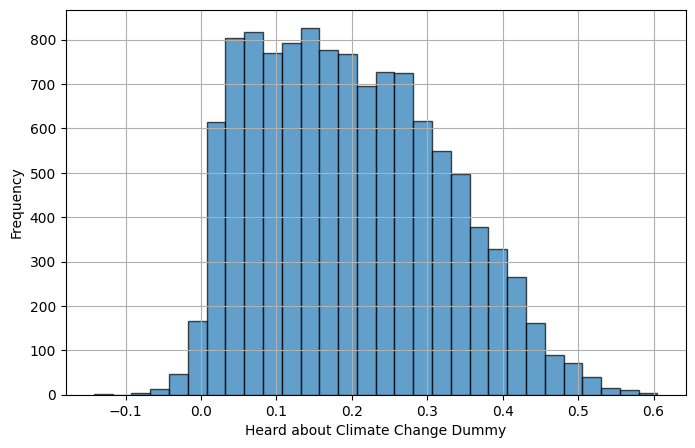

In [68]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Survey Year

In [69]:
name = 'Survey Year'

In [70]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [71]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 2022
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 2016
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [72]:
prob_matrix.mean().mean()

-0.06662927069739898

In [73]:
prob_matrix.mean().std()

0.00494710411371055

In [74]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

-0.0569329466345263

In [75]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

-0.07632559476027165

In [76]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

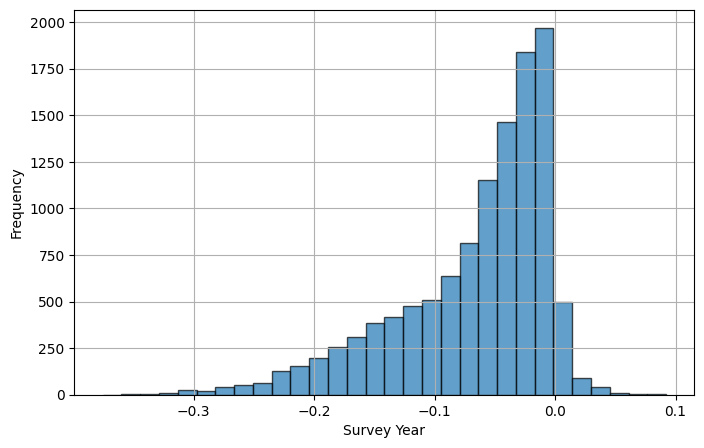

In [77]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()